<a href="https://colab.research.google.com/github/MahsanGhalami/Fundamentals-of-Intelligent-Systems-4041/blob/main/mini2/HW2_Q6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [349]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##PART 1 ) CREATING **DATASET**

1.1.1

In [350]:
T = 1000
y = np.zeros(T)
y[0] = 0.0
y[1] = 0.0
u = np.sin(2 * np.pi * np.arange(T) / 250.0)
for t in range(2, T):
    y[t] = y[t-1] / (1.0 + y[t-2]**2) + u[t-1]**3

Create DataFrame from Time-Series Data

In [351]:
data = {
    "t":[],
    "y_t": [],
    "y_t_1": [],
    "y_t_2": [],
    "u_t_1": [],
}

for k in range(2, T):
    data["y_t_1"].append(y[k-1])
    data["y_t_2"].append(y[k-2])
    data["u_t_1"].append(u[k-1])
    data["y_t"].append(y[k])
    data["t"].append(k)

df = pd.DataFrame(data)
print(df.head())

   t       y_t     y_t_1     y_t_2     u_t_1
0  2  0.000016  0.000000  0.000000  0.025130
1  3  0.000143  0.000016  0.000000  0.050244
2  4  0.000570  0.000143  0.000016  0.075327
3  5  0.001581  0.000570  0.000143  0.100362
4  6  0.003550  0.001581  0.000570  0.125333


1.1.2) test & train

In [352]:
train= df.iloc[:700].reset_index(drop=True)
test = df.iloc[700:].reset_index(drop=True)

print("train:", train.shape)
print("test:", test.shape)

train: (700, 5)
test: (298, 5)


##PART2)  CREATING RBFNN

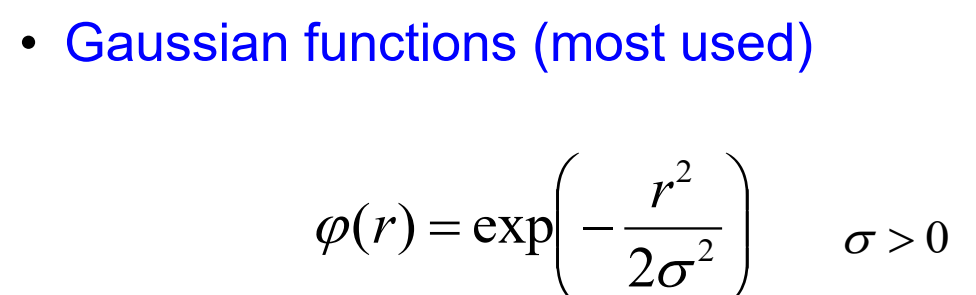

RBF Activation Function

In [353]:
def rbf_activation(x, mu_k, sigma_k):
# Calculating Euclidean distance
    distance = np.linalg.norm(x - mu_k)
#Calcuaating Phi
    return np.exp(- (distance ** 2) / (2 * sigma_k ** 2))

Test RBF Activation Function

In [354]:
x = np.array([1, 1])
mu_k = np.array([1, 1])
sigma_k = 1

output = rbf_activation(x, mu_k, sigma_k)
print("Activation Output:", output)

Activation Output: 1.0


##PART3) TRAINING WITH LLS

In [355]:
X_train = np.array(train[['y_t_1', 'y_t_2', 'u_t_1']])
y_train = np.array(train['y_t'])

num_neurons = 5
# choosing centers(mu_k) randomly
mu_k = X_train[np.random.choice(X_train.shape[0], num_neurons, replace=False)]

# Calculating Spreads: are chosen by normalization
def calculate_sigma(mu_k):
    distances = np.zeros((len(mu_k), len(mu_k)))
    for i in range(len(mu_k)):
        for j in range(len(mu_k)):
            distances[i, j] = np.linalg.norm(mu_k[i] - mu_k[j])
    max_distance = np.max(distances)
    sigma_k = max_distance / np.sqrt(len(mu_k))
    return sigma_k
# Calculating Spreads: are chosen by mean distance between centers
def calculate_sigma_mean(mu_k):
    distances = []
    K = len(mu_k)
    for i in range(K):
        for j in range(i+1, K):
            distances.append(np.linalg.norm(mu_k[i] - mu_k[j]))
    return np.mean(distances)


fixed_sigma = calculate_sigma_mean(mu_k)

#Calculatinf phi Matrixs
def compute_phi(X, mu_k, sigma_k):
    Phi = np.zeros((X.shape[0], len(mu_k)))
    for i in range(X.shape[0]):
        for j in range(len(mu_k)):
            Phi[i, j] = rbf_activation(X[i], mu_k[j], sigma_k)
    return Phi


Phi_train = compute_phi(X_train, mu_k,fixed_sigma)

W = np.linalg.inv(Phi_train.T @ Phi_train) @ Phi_train.T @ y_train


y_pred_train = Phi_train @ W

print("centers", mu_k)
print("W:", W)
print("predictions: ", y_pred_train[:10])

centers [[ 1.38432515  1.36779323  0.97163173]
 [ 1.44534009  1.43618975  0.99361131]
 [-0.8819898  -0.85209417 -0.73751312]
 [ 1.4630239   1.45878502  0.99928947]
 [ 1.19299226  1.21817044  0.88229123]]
W: [-5.20472770e+03  1.62483271e+04 -1.77314400e+00 -1.14961919e+04
  4.54001117e+02]
predictions:  [0.0374656  0.03197134 0.02619583 0.02027374 0.01445173 0.00908034
 0.00460562 0.00156111 0.00056132 0.00229756]


Visualize Training Data and RBF Centers

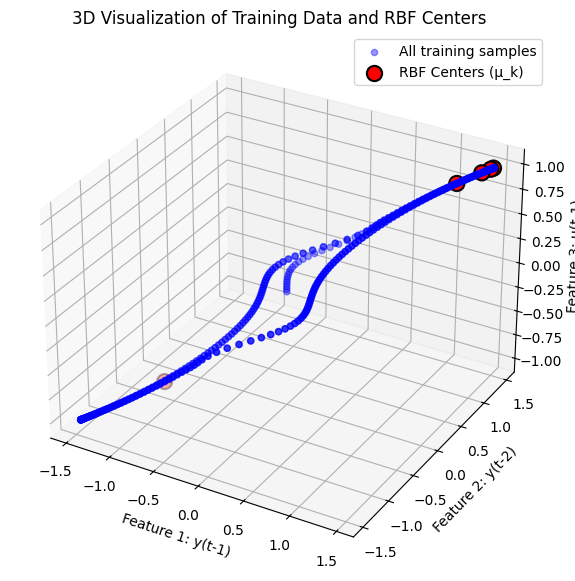

In [356]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_train[:, 0], X_train[:, 1], X_train[:, 2],
    c='blue', alpha=0.4, s=20,
    label='All training samples'
)

#RBF (µ_k)
ax.scatter(
    mu_k[:, 0], mu_k[:, 1], mu_k[:, 2],
    c='red', s=120,
    edgecolors='black',
    linewidths=1.5,
    label='RBF Centers (μ_k)'
)

ax.set_xlabel('Feature 1: y(t-1)')
ax.set_ylabel('Feature 2: y(t-2)')
ax.set_zlabel('Feature 3: u(t-1)')

ax.set_title('3D Visualization of Training Data and RBF Centers')
ax.legend()
plt.show()


Make Predictions on Test Data

In [357]:
X_test = np.array(test[['y_t_1', 'y_t_2', 'u_t_1']])
y_test = np.array(test['y_t'])

Phi_test = compute_phi(X_test, mu_k,fixed_sigma)

y_pred_test = Phi_test @ W

Evaluate Model Performance (RMSE)

In [358]:
from sklearn.metrics import mean_squared_error, r2_score
# MSE
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test, y_pred_test)

# RMSE = sqrt(MSE)
rmse_train = np.sqrt(mse_train)
rmse_test  = np.sqrt(mse_test)


print("Train RMSE:", rmse_train)
print("Test RMSE :", rmse_test)

Train RMSE: 0.11937949343094621
Test RMSE : 0.12925560445045087


#1.3.2)Plot Actual vs. Predicted Outputs for Training Set

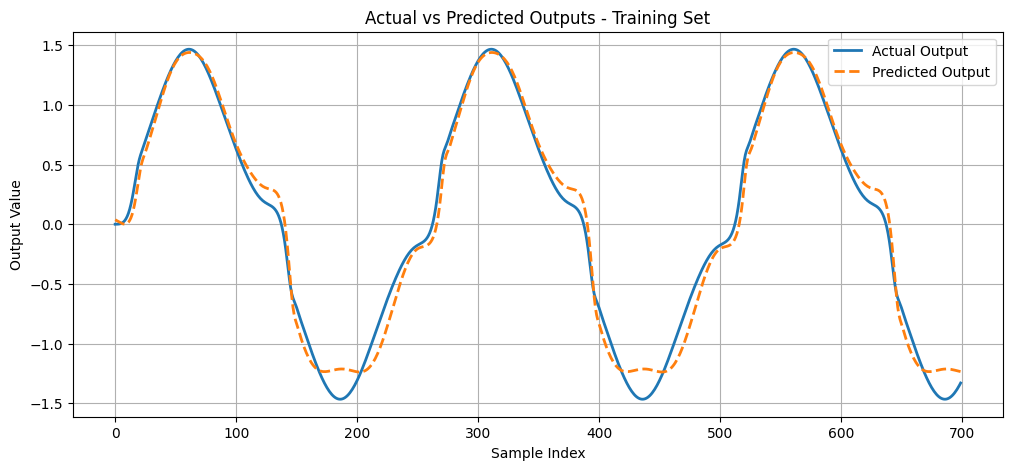

In [359]:
plt.figure(figsize=(12, 5))
plt.plot(y_train, label='Actual Output', linewidth=2)
plt.plot(y_pred_train, label='Predicted Output', linewidth=2, linestyle='--')

plt.xlabel('Sample Index')
plt.ylabel('Output Value')
plt.title('Actual vs Predicted Outputs - Training Set')
plt.legend()
plt.grid(True)
plt.show()

#1.3.3) Plot Actual vs. Predicted Outputs for Test Set

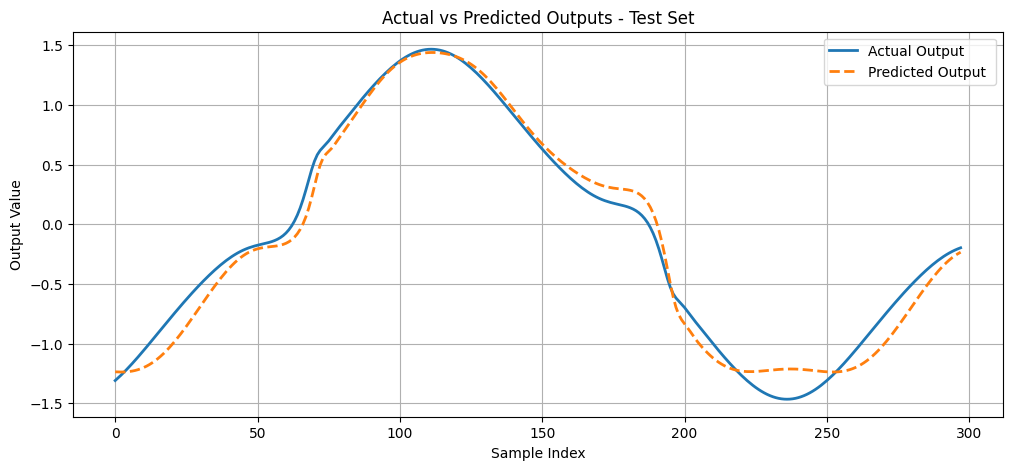

In [360]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual Output', linewidth=2)
plt.plot(y_pred_test, label='Predicted Output ', linewidth=2, linestyle='--')

plt.xlabel('Sample Index')
plt.ylabel('Output Value')
plt.title('Actual vs Predicted Outputs - Test Set')
plt.legend()
plt.grid(True)
plt.show()

#1.3.5)  variuos number of centers & fixed Sigma

In [361]:
K_values = [10, 20, 50, 100, 200]
rmse_test_list = []

for K in K_values:

    mu_k = X_train[np.random.choice(X_train.shape[0], K, replace=False)]
    Phi_train = compute_phi(X_train, mu_k, fixed_sigma)

    W = np.linalg.inv(Phi_train.T @ Phi_train) @ Phi_train.T @ y_train

    Phi_test = compute_phi(X_test, mu_k, fixed_sigma)

    y_pred_test = Phi_test @ W

    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    rmse_test_list.append(rmse_test)

    print(f"K = {K}  -->  Test RMSE = {rmse_test}")


K = 10  -->  Test RMSE = 0.009903506052649448
K = 20  -->  Test RMSE = 1.6915950793862122
K = 50  -->  Test RMSE = 3.53708242385678
K = 100  -->  Test RMSE = 29.47125394939799
K = 200  -->  Test RMSE = 19.238500165140593


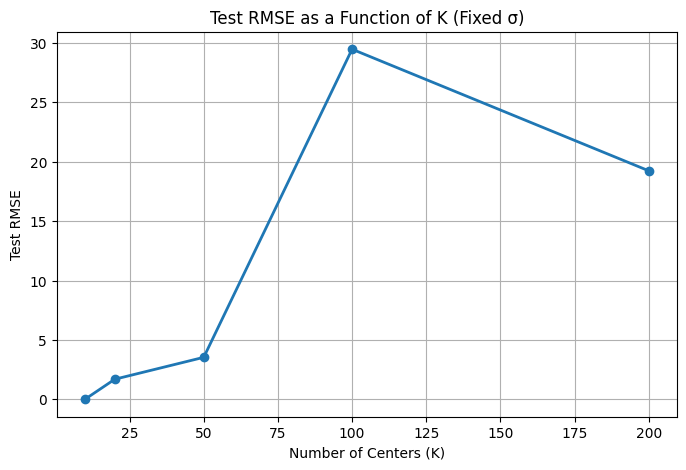

In [362]:
plt.figure(figsize=(8, 5))
plt.plot(K_values, rmse_test_list, marker='o', linewidth=2)
plt.xlabel("Number of Centers (K)")
plt.ylabel("Test RMSE")
plt.title("Test RMSE as a Function of K (Fixed σ)")
plt.grid(True)
plt.show()

Identify Best K Value

In [363]:
best_index = np.argmin(rmse_test_list)
best_K = K_values[best_index]
best_rmse = rmse_test_list[best_index]

print("Best K:", best_K)
print("Min Test RMSE:", best_rmse)

Best K: 10
Min Test RMSE: 0.009903506052649448


#1.3.5) fixed number of centers & various Sigma

In [364]:
K = best_K

mu_k = X_train[np.random.choice(X_train.shape[0], K, replace=False)]

sigma_values = [0.5, 1, 5, 7, 10]
rmse_test_list = []

for sigma in sigma_values:

    Phi_train = compute_phi(X_train, mu_k, sigma)

    # Use np.linalg.pinv() for more robust inversion, especially with singular or ill-conditioned matrices
    W = np.linalg.pinv(Phi_train.T @ Phi_train) @ Phi_train.T @ y_train

    Phi_test = compute_phi(X_test, mu_k, sigma)

    y_pred_test = Phi_test @ W

    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    rmse_test_list.append(rmse_test)

    print(f"sigma = {sigma}  -->  Test RMSE = {rmse_test}")

sigma = 0.5  -->  Test RMSE = 0.08937431872111276
sigma = 1  -->  Test RMSE = 0.03285078755314923
sigma = 5  -->  Test RMSE = 0.0033226865637054903
sigma = 7  -->  Test RMSE = 0.003035529052548437
sigma = 10  -->  Test RMSE = 0.003098486144284407


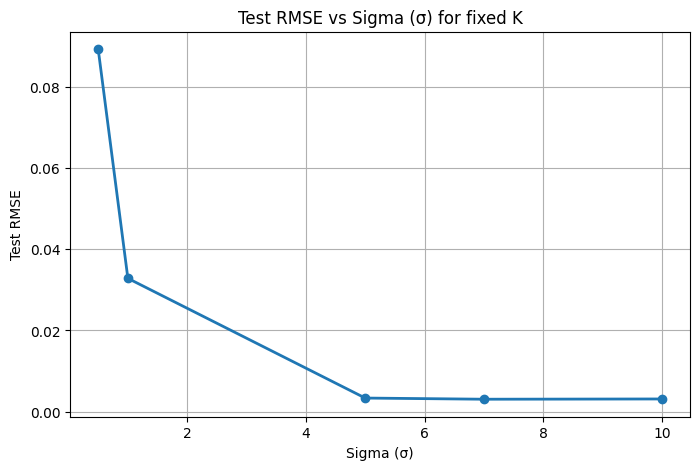

In [365]:
plt.figure(figsize=(8, 5))
plt.plot(sigma_values, rmse_test_list, marker='o', linewidth=2)
plt.xlabel("Sigma (σ)")
plt.ylabel("Test RMSE")
plt.title("Test RMSE vs Sigma (σ) for fixed K")
plt.grid(True)
plt.show()

In [366]:
best_index = np.argmin(rmse_test_list)
best_sigma = sigma_values[best_index]
best_rmse = rmse_test_list[best_index]

print("Best sigma:", best_sigma)
print("Min Test RMSE:", best_rmse)

Best sigma: 7
Min Test RMSE: 0.003035529052548437


In [367]:
mu_k_final = mu_k

Phi_train_final = compute_phi(X_train, mu_k_final, best_sigma)
W_final = np.linalg.pinv(Phi_train_final) @ y_train
Phi_test_final = compute_phi(X_test, mu_k_final, best_sigma)
y_pred_test_final = Phi_test_final @ W_final

final_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_final))
print("Final Test RMSE with best K and σ:", final_rmse_test)

Final Test RMSE with best K and σ: 0.003027909159265722


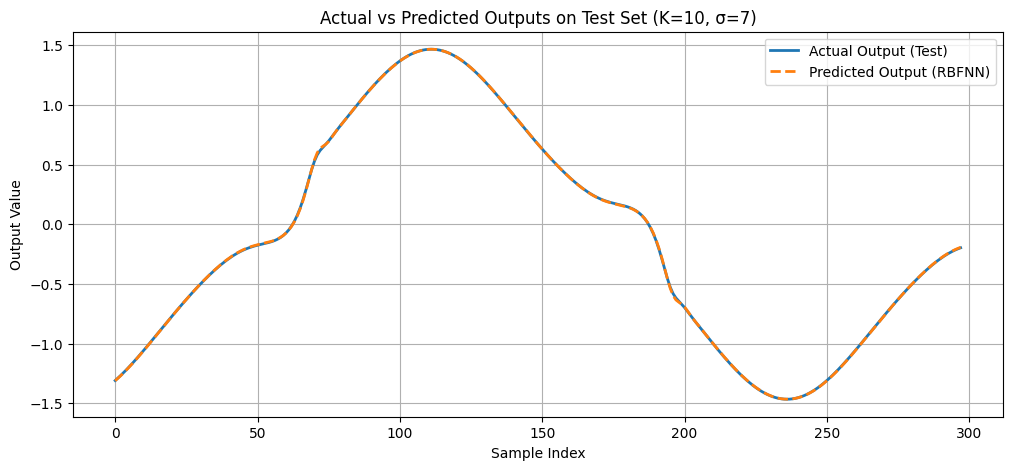

In [368]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual Output (Test)', linewidth=2)
plt.plot(y_pred_test_final, label='Predicted Output (RBFNN)', linewidth=2, linestyle='--')

plt.xlabel('Sample Index')
plt.ylabel('Output Value')
plt.title(f'Actual vs Predicted Outputs on Test Set (K={best_K}, σ={best_sigma})')
plt.legend()
plt.grid(True)
plt.show()

In [369]:
def train_rbf_l2(X_train, y_train, mu_k, sigma, lam):

    Phi_train = compute_phi(X_train, mu_k, sigma)
    K = Phi_train.shape[1]

    A = Phi_train.T @ Phi_train + lam * np.eye(K)
    b = Phi_train.T @ y_train

    alpha = np.linalg.pinv(A) @ b

    y_pred_train = Phi_train @ alpha
    return alpha, y_pred_train

In [370]:
K_large = 200
mu_k = X_train[np.random.choice(X_train.shape[0], K_large, replace=False)]
sigma_large = calculate_sigma_mean(mu_k)

lambda_values = [0.001, 0.01, 0.1, 1, 10]
rmse_test_list = []

for lam in lambda_values:
    alpha_l2, y_pred_train_l2 = train_rbf_l2(X_train, y_train, mu_k, sigma_large, lam)
    Phi_test = compute_phi(X_test, mu_k, fixed_sigma)
    y_pred_test_l2 = Phi_test @ alpha_l2

    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_l2))
    rmse_test_list.append(rmse_test)

    print(f"lambda = {lam}  -->  Test RMSE = {rmse_test}")

lambda = 0.001  -->  Test RMSE = 0.08035802904385354
lambda = 0.01  -->  Test RMSE = 0.0670925025052976
lambda = 0.1  -->  Test RMSE = 0.0721689103614957
lambda = 1  -->  Test RMSE = 0.06404687782686179
lambda = 10  -->  Test RMSE = 0.053367260089828866


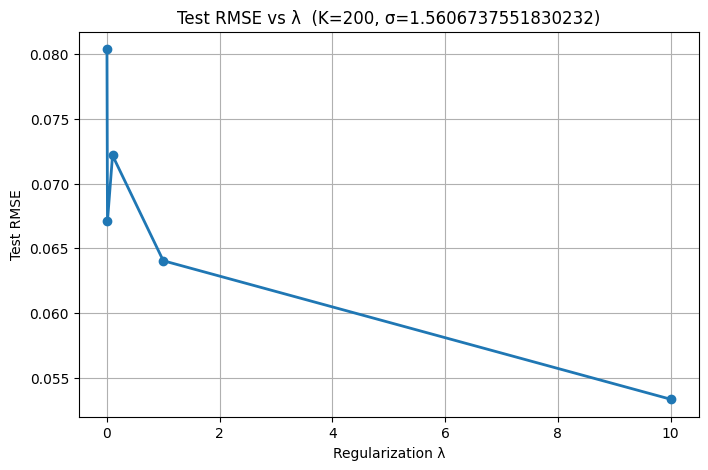

In [371]:
plt.figure(figsize=(8, 5))
plt.plot(lambda_values, rmse_test_list, marker='o', linewidth=2)
plt.xlabel("Regularization λ")
plt.ylabel("Test RMSE")
plt.title(f"Test RMSE vs λ  (K={K_large}, σ={fixed_sigma})")
plt.grid(True)
plt.show()

In [372]:
best_idx = np.argmin(rmse_test_list)
best_lambda = lambda_values[best_idx]
best_rmse_l2 = rmse_test_list[best_idx]

print("Best λ:", best_lambda)
print("Min Test RMSE with L2:", best_rmse_l2)

Best λ: 10
Min Test RMSE with L2: 0.053367260089828866


In [373]:
Phi_train = compute_phi(X_train, mu_k, sigma_large)
alpha_noreg = np.linalg.pinv(Phi_train) @ y_train

Phi_test = compute_phi(X_test, mu_k, sigma_large)
y_pred_test_noreg = Phi_test @ alpha_noreg

rmse_test_noreg = np.sqrt(mean_squared_error(y_test, y_pred_test_noreg))
print("Test RMSE without regularization:", rmse_test_noreg)

Test RMSE without regularization: 0.0002956269148568171


In [374]:
alpha_best_l2, _ = train_rbf_l2(X_train, y_train, mu_k, sigma_large, best_lambda)
y_pred_test_best_l2 = Phi_test @ alpha_best_l2

rmse_test_best_l2 = np.sqrt(mean_squared_error(y_test, y_pred_test_best_l2))
print("Test RMSE with best λ:", rmse_test_best_l2)

Test RMSE with best λ: 0.07334129359871468


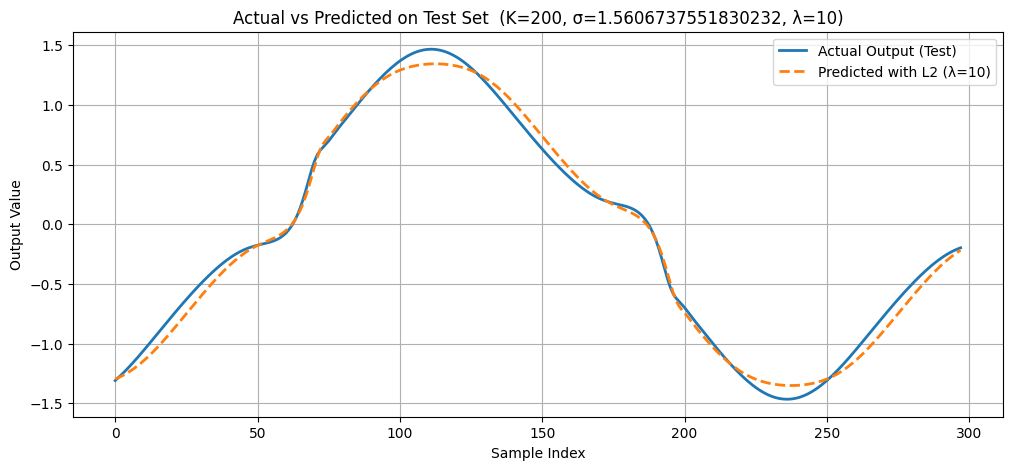

In [375]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual Output (Test)', linewidth=2)
plt.plot(y_pred_test_best_l2, label=f'Predicted with L2 (λ={best_lambda})',
         linewidth=2, linestyle='--')

plt.xlabel('Sample Index')
plt.ylabel('Output Value')
plt.title(f'Actual vs Predicted on Test Set  (K={K_large}, σ={fixed_sigma}, λ={best_lambda})')
plt.legend()
plt.grid(True)
plt.show()


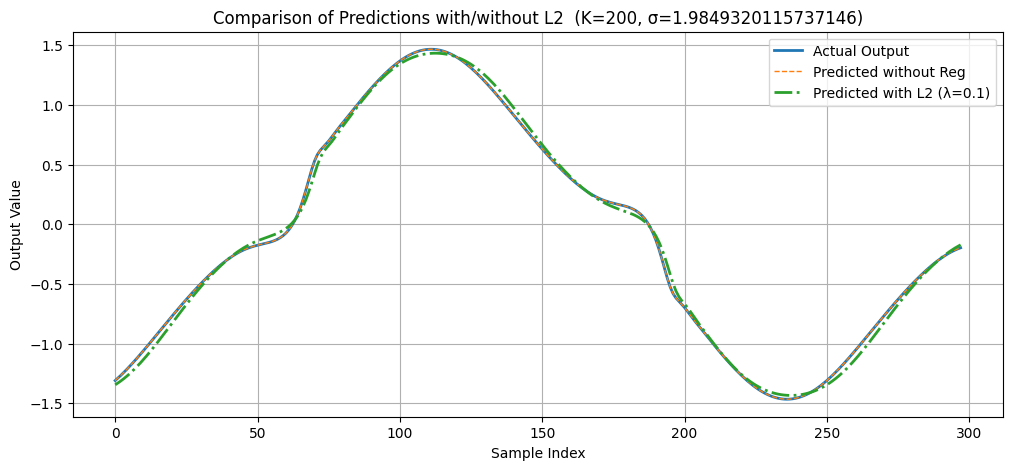

In [331]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual Output', linewidth=2)
plt.plot(y_pred_test_noreg, label='Predicted without Reg', linewidth=1, linestyle='--')
plt.plot(y_pred_test_best_l2, label=f'Predicted with L2 (λ={best_lambda})',
         linewidth=2, linestyle='-.')
plt.xlabel('Sample Index')
plt.ylabel('Output Value')
plt.title(f'Comparison of Predictions with/without L2  (K={K_large}, σ={fixed_sigma})')
plt.legend()
plt.grid(True)
plt.show()


##PART5) ⅽⅼustering K−Ⅿeans & Nearest−Neighbor

#ⅽⅼustering K−Ⅿeans

In [332]:
from sklearn.cluster import KMeans

K = 5
kmeans = KMeans(n_clusters=K, random_state=0)
kmeans.fit(X_train)
mu_k = kmeans.cluster_centers_


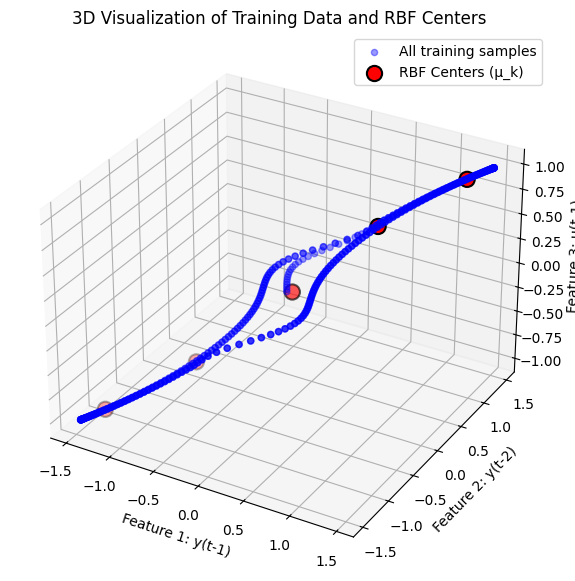

In [333]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_train[:, 0], X_train[:, 1], X_train[:, 2],
    c='blue', alpha=0.4, s=20,
    label='All training samples'
)

#RBF (µ_k)
ax.scatter(
    mu_k[:, 0], mu_k[:, 1], mu_k[:, 2],
    c='red', s=120,
    edgecolors='black',
    linewidths=1.5,
    label='RBF Centers (μ_k)'
)

ax.set_xlabel('Feature 1: y(t-1)')
ax.set_ylabel('Feature 2: y(t-2)')
ax.set_zlabel('Feature 3: u(t-1)')

ax.set_title('3D Visualization of Training Data and RBF Centers')
ax.legend()
plt.show()

In [334]:
sigma_k = calculate_sigma(mu_k)

Phi_train = compute_phi(X_train, mu_k, sigma_k)
W = np.linalg.pinv(Phi_train) @ y_train
Phi_test = compute_phi(X_test, mu_k, sigma_k)

y_pred_test = Phi_test @ W

In [335]:
rmse_test_kmeans = np.sqrt(mean_squared_error(y_test, y_pred_test))
print("Test RMSE with K-Means centers:", rmse_test_kmeans)

Test RMSE with K-Means centers: 0.04213920944168215


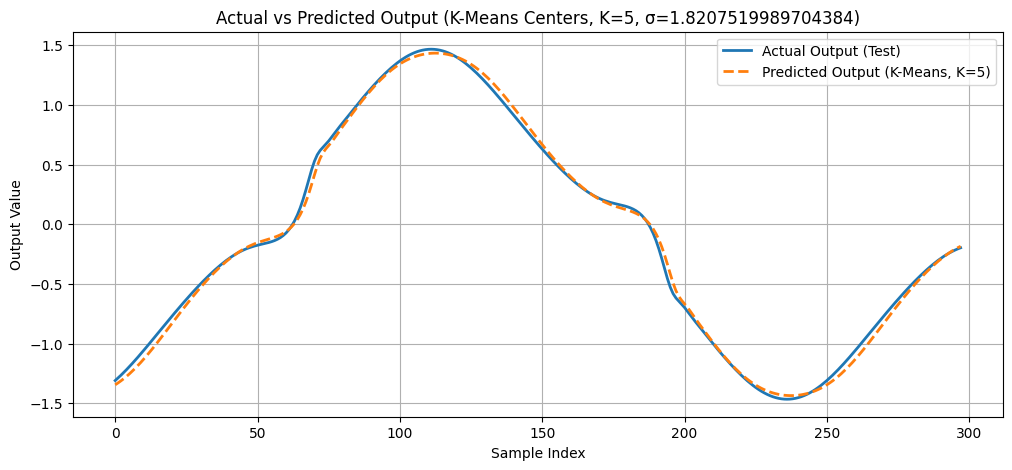

In [336]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual Output (Test)', linewidth=2)
plt.plot(y_pred_test, label=f'Predicted Output (K-Means, K={K})',
         linewidth=2, linestyle='--')

plt.xlabel('Sample Index')
plt.ylabel('Output Value')
plt.title(f'Actual vs Predicted Output (K-Means Centers, K={K}, σ={sigma_k})')
plt.legend()
plt.grid(True)
plt.show()

#Nearest−Neighbor

In [337]:
def compute_sigmas_nearest_neighbor(mu_k, p=2):
    K = len(mu_k)
    sigmas = np.zeros(K)

    for i in range(K):
        distances = np.linalg.norm(mu_k[i] - mu_k, axis=1)
        distances = np.delete(distances, i)
        distances_sorted = np.sort(distances)
        sigmas[i] = np.mean(distances_sorted[:p])

    return sigmas

In [338]:
def compute_phi_variable_sigma(X, mu_k, sigma_vec):
    N = X.shape[0]
    K = len(mu_k)
    Phi = np.zeros((N, K))

    for i in range(N):
        for j in range(K):
            Phi[i, j] = rbf_activation(X[i], mu_k[j], sigma_vec[j])

    return Phi

In [339]:
sigma_vec = compute_sigmas_nearest_neighbor(mu_k, p=2)

Phi_train = compute_phi_variable_sigma(X_train, mu_k, sigma_vec)

W = np.linalg.pinv(Phi_train) @ y_train

Phi_test = compute_phi_variable_sigma(X_test, mu_k, sigma_vec)
y_pred_train = Phi_train @ W
y_pred_test = Phi_test @ W

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

print("Train RMSE:", rmse_train)
print("Test  RMSE:", rmse_test)

Train RMSE: 0.0521912833850902
Test  RMSE: 0.05534665913231117


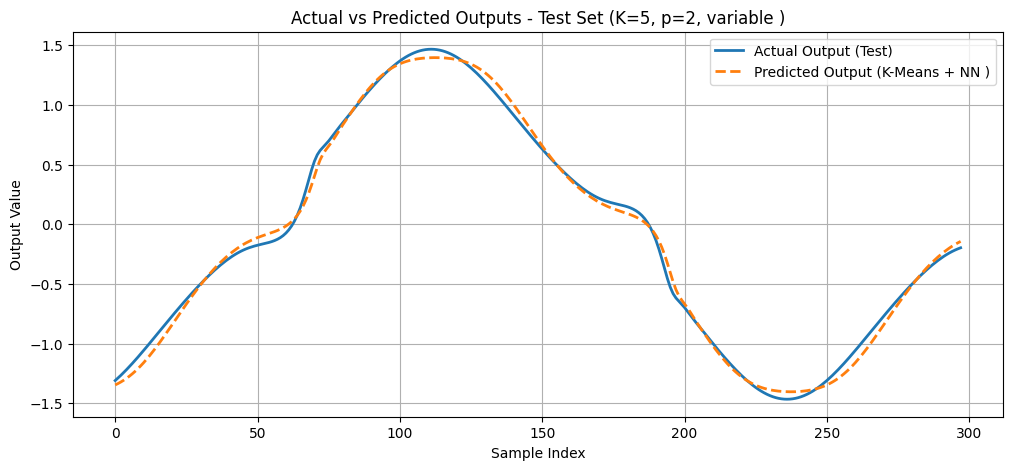

In [340]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual Output (Test)', linewidth=2)
plt.plot(y_pred_test, label='Predicted Output (K-Means + NN )',
         linewidth=2, linestyle='--')

plt.xlabel('Sample Index')
plt.ylabel('Output Value')
plt.title(f'Actual vs Predicted Outputs - Test Set (K={K}, p=2, variable )')
plt.legend()
plt.grid(True)
plt.show()

# PART 2 - RAN-style RBFNN

#2.1.1) Growth Criterion

In [341]:
def should_add_neuron(x_n, y_n, y_pred, mu_k, epsilon=1.0, e_min=0.5):
    if mu_k is None or len(mu_k) == 0:
        return True
    mu_array = np.array(mu_k)
    dists = np.linalg.norm(mu_array - x_n, axis=1)
    d_min = np.min(dists)

   #condition1
    novelty = d_min > epsilon

   #condition2
    error_big = abs(y_n - y_pred) > e_min

    return novelty and error_big

In [342]:
x_test_sample = np.array([1.0, 0.5, -0.2])
y_true_sample = 0.8
y_pred_sample = 0.1

mu_test = np.array([
    [0.0, 0.0, 0.0],
    [1.5, 1.2, -0.1]
])

epsilon_test = 1.0
emin_test = 0.5

print("Should add neuron? ->",
      should_add_neuron(x_test_sample, y_true_sample, y_pred_sample,
                        mu_test, epsilon=epsilon_test, e_min=emin_test))


Should add neuron? -> False


Growing network with should_add_neuron

In [343]:
from sklearn.metrics import mean_squared_error

epsilon = 1.0
e_min   = 0.5
eta     = 0.05 #learning rate

sigma_ran = 1.0
centers = []
W = None

y_pred_train_seq = []

N_train = X_train.shape[0]

for n in range(N_train):
    x_n = X_train[n]
    y_n = y_train[n]

    if len(centers) == 0:
        centers.append(x_n.copy())
        mu_k = np.array(centers)

        Phi_seen = compute_phi(X_train[:n+1], mu_k, sigma_ran)
        W = np.linalg.pinv(Phi_seen) @ y_train[:n+1]
        y_pred_n = Phi_seen[-1] @ W

    else:
        mu_k = np.array(centers)
        phi_n = np.array([rbf_activation(x_n, c, sigma_ran) for c in mu_k])
        y_pred_n = phi_n @ W
        add = should_add_neuron(x_n, y_n, y_pred_n, mu_k,
                                epsilon=epsilon, e_min=e_min)
        if add:
            # appending new neroun
            centers.append(x_n.copy())
            mu_k = np.array(centers)
            Phi_seen = compute_phi(X_train[:n+1], mu_k, sigma_ran)
            W = np.linalg.pinv(Phi_seen) @ y_train[:n+1]
            y_pred_n = Phi_seen[-1] @ W
        else:
            # not need a new neroun just updating
            e_n = y_n - y_pred_n
            W = W + eta * e_n * phi_n

    y_pred_train_seq.append(y_pred_n)

y_pred_train_seq = np.array(y_pred_train_seq)

Number of hidden neurons after sequential training: 5
Sequential RAN-style Train RMSE: 0.13765719759247957
Sequential RAN-style Test  RMSE: 0.17903581037453603


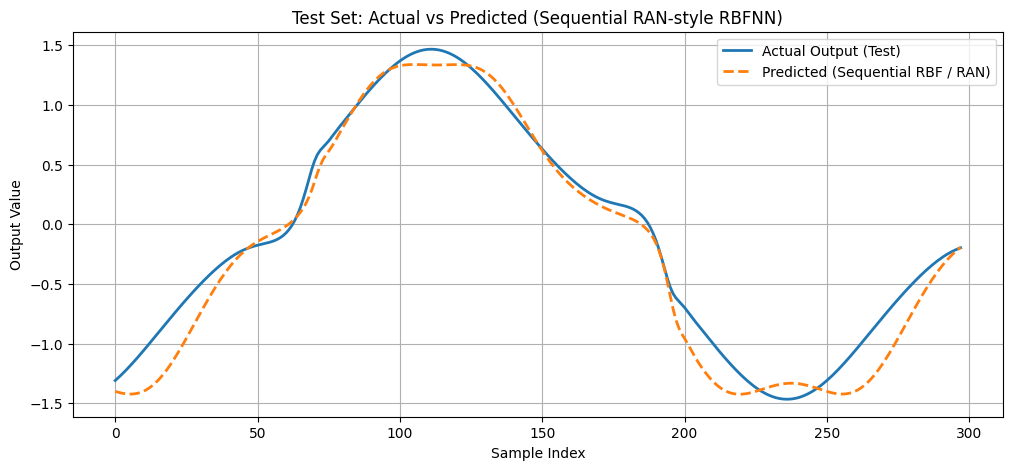

In [344]:
mu_k_final = np.array(centers)
Phi_test_seq = compute_phi(X_test, mu_k_final, sigma_ran)
y_pred_test_seq = Phi_test_seq @ W

rmse_train_seq = np.sqrt(mean_squared_error(y_train, y_pred_train_seq))
rmse_test_seq  = np.sqrt(mean_squared_error(y_test,  y_pred_test_seq))

print(f"Number of hidden neurons after sequential training: {len(centers)}")
print("Sequential RAN-style Train RMSE:", rmse_train_seq)
print("Sequential RAN-style Test  RMSE:", rmse_test_seq)

plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual Output (Test)', linewidth=2)
plt.plot(y_pred_test_seq, label='Predicted (Sequential RBF / RAN)',
         linewidth=2, linestyle='--')
plt.xlabel("Sample Index")
plt.ylabel("Output Value")
plt.title("Test Set: Actual vs Predicted (Sequential RAN-style RBFNN)")
plt.legend()
plt.grid(True)
plt.show()

#2.2) Adaptive RBFNN (M-RAN style) + Pruning

In [345]:
def train_mran(epsilon, e_min,
               delta=0.1, M=60, kappa=0.8, eta=0.05,
               verbose=False):
    centers = []
    sigmas = []
    W = None
    pruning_counters = []
    hidden_counts = []
    y_pred_train_seq = []

    N_train = X_train.shape[0]

    for n in range(N_train):

        x_n = X_train[n]
        y_n = y_train[n]

        if len(centers) == 0:
            centers.append(x_n.copy())
            sigmas.append(1.0)          # initial spread
            W = np.array([y_n], float)  # w1 = y_n

            pruning_counters = [0]

            mu_k = np.array(centers)
            sigma_vec = np.array(sigmas)
            phi_n = np.array([rbf_activation(x_n, mu_k[0], sigma_vec[0])])
            y_pred_n = W @ phi_n

        else:
            mu_k = np.array(centers)
            sigma_vec = np.array(sigmas)

            # current activations and output
            phi_n = np.array([rbf_activation(x_n, mu_k[j], sigma_vec[j])
                              for j in range(len(centers))])
            y_pred_n = phi_n @ W
            e_n = y_n - y_pred_n

            #growth condition (novelty + large error)
            add = should_add_neuron(x_n, y_n, y_pred_n, mu_k,
                                    epsilon=epsilon, e_min=e_min)

            if add:
                # nearest existing center
                dists = np.linalg.norm(mu_k - x_n, axis=1)
                nearest_idx = np.argmin(dists)
                nearest_center = mu_k[nearest_idx]

                # add new center
                centers.append(x_n.copy())

                # new spread based on distance to nearest center
                new_sigma = kappa * np.linalg.norm(x_n - nearest_center)
                if new_sigma < 1e-3:
                    new_sigma = 1e-3
                sigmas.append(new_sigma)

                # new weight w_{K+1} = e_n
                W = np.concatenate([W, np.array([e_n])])

                # new pruning counter
                pruning_counters.append(0)

            else:
                # ---- LMS update if no new neuron is added ----
                W = W + eta * e_n * phi_n

            # recompute activations with possibly updated network
            mu_k = np.array(centers)
            sigma_vec = np.array(sigmas)
            phi_n = np.array([rbf_activation(x_n, mu_k[j], sigma_vec[j])
                              for j in range(len(centers))])
            y_pred_n = phi_n @ W

            # ------------- PRUNING PHASE -------------
            o_n = W * phi_n
            o_max = np.max(np.abs(o_n))

            if o_max > 0:
                r_n = np.abs(o_n) / o_max
            else:
                r_n = np.zeros_like(o_n)

            for k in range(len(centers)):
                if r_n[k] < delta:
                    pruning_counters[k] += 1
                else:
                    pruning_counters[k] = 0

            # indices to prune
            to_prune = [k for k, c in enumerate(pruning_counters) if c > M]

            # PRUNING METHOD
            for idx in sorted(to_prune, reverse=True):
            # delete center, sigma, pruning counter, and weight of neuron k
                del centers[idx]
                del sigmas[idx]
                del pruning_counters[idx]
                W = np.delete(W, idx)

        hidden_counts.append(len(centers))
        y_pred_train_seq.append(y_pred_n)

    y_pred_train_seq = np.array(y_pred_train_seq)

    # ---- evaluate on full train and test sets ----
    mu_k_final = np.array(centers)
    sigma_vec_final = np.array(sigmas)

    Phi_train_adapt = compute_phi_variable_sigma(X_train, mu_k_final, sigma_vec_final)
    y_pred_train_adapt = Phi_train_adapt @ W

    Phi_test_adapt = compute_phi_variable_sigma(X_test, mu_k_final, sigma_vec_final)
    y_pred_test_adapt = Phi_test_adapt @ W

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train_adapt))
    rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test_adapt))


    return (centers, sigmas, W,
            y_pred_train_seq, hidden_counts,
            rmse_train, rmse_test)


Grid search over (epsilon, e_min)

In [346]:
epsilon_grid = [0.5, 1.0, 1.5, 2.0]
e_min_grid   = [0.05, 0.10, 0.15, 0.20]

results = []

best_cfg = None
best_rmse_test = np.inf
best_model = None

for eps in epsilon_grid:
    for e_min in e_min_grid:

        (centers, sigmas, W,
         y_pred_train_seq, hidden_counts,
         rmse_train, rmse_test) = train_mran(
            epsilon=eps,
            e_min=e_min,
            delta=0.1,
            M=60,
            kappa=0.8,
            eta=0.05,
        )

        results.append({
            "epsilon": eps,
            "e_min": e_min,
            "rmse_train": rmse_train,
            "rmse_test": rmse_test,
            "final_hidden": len(centers)
        })

        # keep track of best configuration based on test RMSE
        if rmse_test < best_rmse_test:
            best_rmse_test = rmse_test
            best_cfg = (eps, e_min)
            best_model = (centers, sigmas, W,
                          y_pred_train_seq, hidden_counts)

print("\nBest hyperparameters based on test RMSE:")
print(f"  epsilon = {best_cfg[0]}")
print(f"  e_min   = {best_cfg[1]}")
print(f"  best test RMSE = {best_rmse_test:.6f}")
print(f"  final hidden units = {len(best_model[0])}")



Best hyperparameters based on test RMSE:
  epsilon = 1.0
  e_min   = 0.05
  best test RMSE = 0.646666
  final hidden units = 5


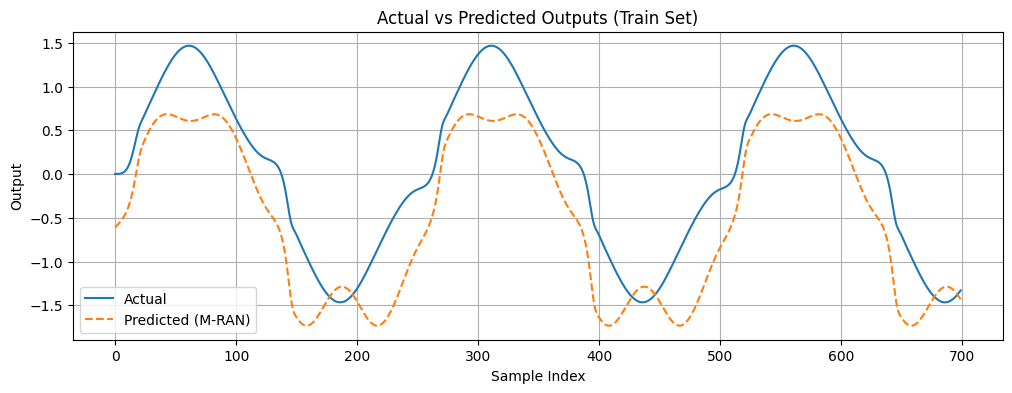

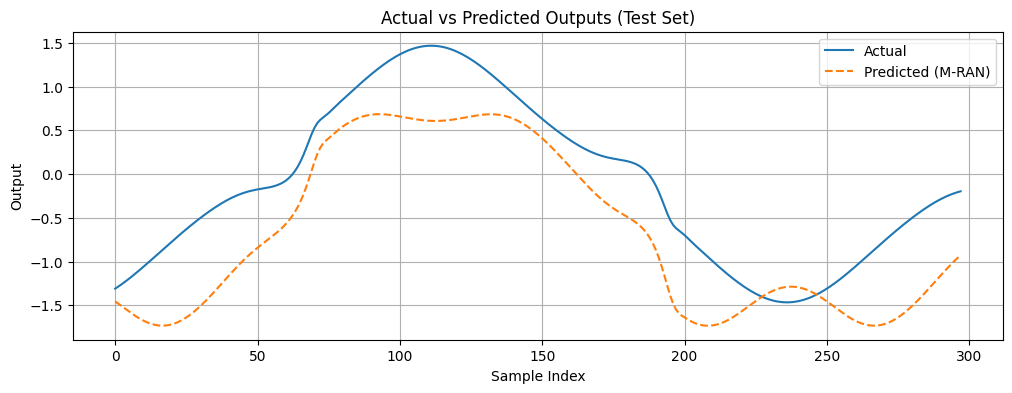

In [347]:
# -------------------------------# Calculate final predictions using the best model parameters
best_centers, best_sigmas, best_W, _, _ = best_model

# Compute Phi matrix for training data with best parameters
Phi_train_best = compute_phi_variable_sigma(X_train, np.array(best_centers), np.array(best_sigmas))
y_pred_train_best = Phi_train_best @ best_W

# Compute Phi matrix for test data with best parameters
Phi_test_best = compute_phi_variable_sigma(X_test, np.array(best_centers), np.array(best_sigmas))
y_pred_test_best = Phi_test_best @ best_W

# Plot: Actual vs Predicted (Train)
# -------------------------------
plt.figure(figsize=(12, 4))
plt.plot(y_train, label="Actual")
plt.plot(y_pred_train_best, label="Predicted (M-RAN)", linestyle="--")
plt.xlabel("Sample Index")
plt.ylabel("Output")
plt.title("Actual vs Predicted Outputs (Train Set)")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Plot: Actual vs Predicted (Test)
# -------------------------------
plt.figure(figsize=(12, 4))
plt.plot(y_test, label="Actual")
plt.plot(y_pred_test_best, label="Predicted (M-RAN)", linestyle="--")
plt.xlabel("Sample Index")
plt.ylabel("Output")
plt.title("Actual vs Predicted Outputs (Test Set)")
plt.legend()
plt.grid(True)
plt.show()

2.2.3)

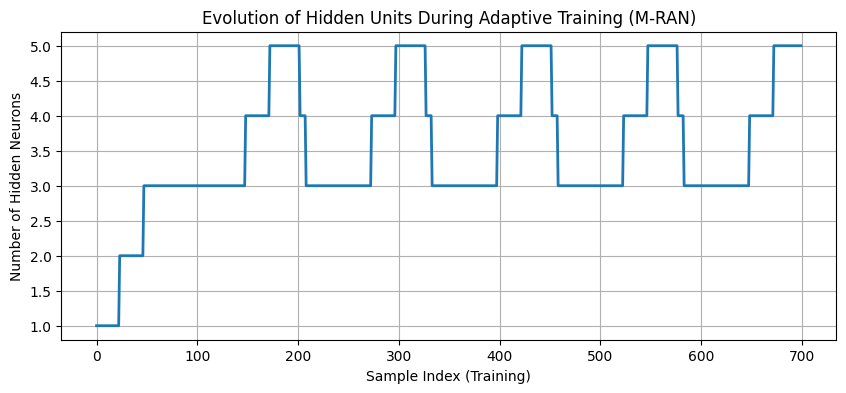

In [348]:
best_centers, best_sigmas, best_W, _, best_hidden_counts = best_model # Unpack best_hidden_counts from best_model

plt.figure(figsize=(10, 4))
plt.plot(best_hidden_counts, linewidth=2)
plt.xlabel("Sample Index (Training)")
plt.ylabel("Number of Hidden Neurons")
plt.title("Evolution of Hidden Units During Adaptive Training (M-RAN)")
plt.grid(True)
plt.show()